<u><h1>CPSC 440 Project: Road Traffic Accident Dataset Analysis</h1></u>

Reproducing: "Evaluating Road Crash Severity Prediction with Balanced Ensemble Models"
By Alexei Roudnitski (2024) — Published in Findings
DOI: https://doi.org/10.32866/001c.116820

Data source: https://opendata.transport.nsw.gov.au/dataset/nsw-crash-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
# load data
DATA_PATH = "data/nsw_road_crash_data_2018-2022_crash.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1")

In [3]:
# select columns
TARGET = "Degree of crash - detailed"

FEATURES = [
    "Day of week of crash",
    "Distance",
    "Identifying feature type",
    "Type of location",
    "Urbanisation",
    "Alignment",
    "Street lighting",
    "Road surface",
    "Surface condition",
    "Weather",
    "Natural lighting",
    "Signals operation",
    "Other traffic control",
    "Speed limit",
    "Road classification (admin)",
    "First impact type",
    "Key TU type",
    "Other TU type",
    "No. of traffic units involved",
]

df = df[[TARGET] + FEATURES].copy()
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}")

Dataset shape: (95873, 20)

Target distribution:
Degree of crash - detailed
Non-casualty (towaway)    30771
Moderate Injury           26740
Serious Injury            19700
Minor/Other Injury        17220
Fatal                      1442
Name: count, dtype: int64


In [4]:
# remove rows with unknown values
def remove_unknown_strings_only(df):
    """
    Removes rows where any of the 20 columns contain the word 'unknown',
    but preserves rows that contain actual NaN/Null values.
    """
    # The 20 variables identified in the paper
    features = FEATURES
    
    # Create a mask for 'unknown'
    # We cast to string to use .str.contains, but we must handle NaNs 
    # so they don't get caught in the 'unknown' filter.
    contains_unknown = df[features].apply(
        lambda col: col.astype(str).str.contains('unknown', case=False, na=False)
    ).any(axis=1)
    
    # Filter the dataframe
    df_no_unknowns = df[~contains_unknown].copy()
    
    # Validation
    unknown_count = contains_unknown.sum()
    null_count = df_no_unknowns[features].isnull().any(axis=1).sum()
    
    print(f"Rows removed due to 'unknown' string: {unknown_count}")
    print(f"Rows remaining that still contain NaNs: {null_count}")
    print(f"New dataset shape: {df_no_unknowns.shape}")
    
    return df_no_unknowns

df = remove_unknown_strings_only(df)
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}")

Rows removed due to 'unknown' string: 39076
Rows remaining that still contain NaNs: 20228
New dataset shape: (56797, 20)

Target distribution:
Degree of crash - detailed
Moderate Injury           20224
Serious Injury            17979
Non-casualty (towaway)     9657
Minor/Other Injury         7528
Fatal                      1409
Name: count, dtype: int64


In [5]:
# encode categorical variables
label_encoders = {}
for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = df[col].fillna("Missing")
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

X = df[FEATURES]
y = df[TARGET]


In [6]:

# test/train split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=440, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 39757, Test size: 17040


In [7]:
# apply SMOTE on train data
smote = SMOTE(random_state=440)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"Balanced train size: {X_train_bal.shape[0]}")
print(f"Balanced class distribution:\n{pd.Series(y_train_bal).value_counts()}")

Balanced train size: 70780
Balanced class distribution:
Degree of crash - detailed
2    14156
3    14156
4    14156
1    14156
0    14156
Name: count, dtype: int64


In [8]:
# models for ensemble model using paper's hyperparams
rf = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=440,
)

xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=1,
    n_estimators=100,
    eval_metric="mlogloss",
    random_state=440,
)

ada = AdaBoostClassifier(
    learning_rate=0.1,
    n_estimators=50,
    random_state=440,
    algorithm="SAMME",
)

lgbm = LGBMClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    random_state=440,
    verbose=-1,
)

cat = CatBoostClassifier(
    learning_rate=0.1,
    max_depth=3,
    iterations=100,
    random_seed=440,
    verbose=0,
)

In [9]:
# soft voting ensemble
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("ada", ada),
        ("lgbm", lgbm),
        ("cat", cat),
    ],
    voting="soft",
)

print("\nTraining ensemble model")
ensemble.fit(X_train_bal, y_train_bal)
print("Training complete.")


Training ensemble model


c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Training complete.


In [10]:
# AUC and feature importances per model
models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "AdaBoost": ada,
    "LightGBM": lgbm,
    "CatBoost": cat,
}

individual_importances = {}
individual_aucs = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    proba = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
    individual_aucs[name] = auc
    individual_importances[name] = model.feature_importances_
    print(f"{name} — individual AUC: {auc:.3f}")

# weight importances by model AUC, then average and normalize
weighted_sum = np.zeros(len(FEATURES))
total_weight = 0
for name in models:
    w = individual_aucs[name]
    weighted_sum += w * individual_importances[name]
    total_weight += w

weighted_importance = weighted_sum / total_weight
weighted_importance = weighted_importance / weighted_importance.sum()

importance_df = (
    pd.DataFrame({"Feature": FEATURES, "Importance": weighted_importance})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 Weighted Feature Importances:")
print(importance_df.head(20).to_string(index=False))

Random Forest — individual AUC: 0.672
XGBoost — individual AUC: 0.673


c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost — individual AUC: 0.616
LightGBM — individual AUC: 0.676
CatBoost — individual AUC: 0.665

Top 20 Weighted Feature Importances:
                      Feature  Importance
                  Key TU type    0.133084
                Other TU type    0.131764
            First impact type    0.131539
                  Speed limit    0.081924
                     Distance    0.064297
                 Urbanisation    0.060674
No. of traffic units involved    0.050546
     Identifying feature type    0.049073
             Natural lighting    0.042624
              Street lighting    0.041125
         Day of week of crash    0.034205
  Road classification (admin)    0.033148
             Type of location    0.032020
            Surface condition    0.025135
        Other traffic control    0.023780
                      Weather    0.023341
                    Alignment    0.019293
            Signals operation    0.012138
                 Road surface    0.010288



Feature importance plot saved to feature_importance.png


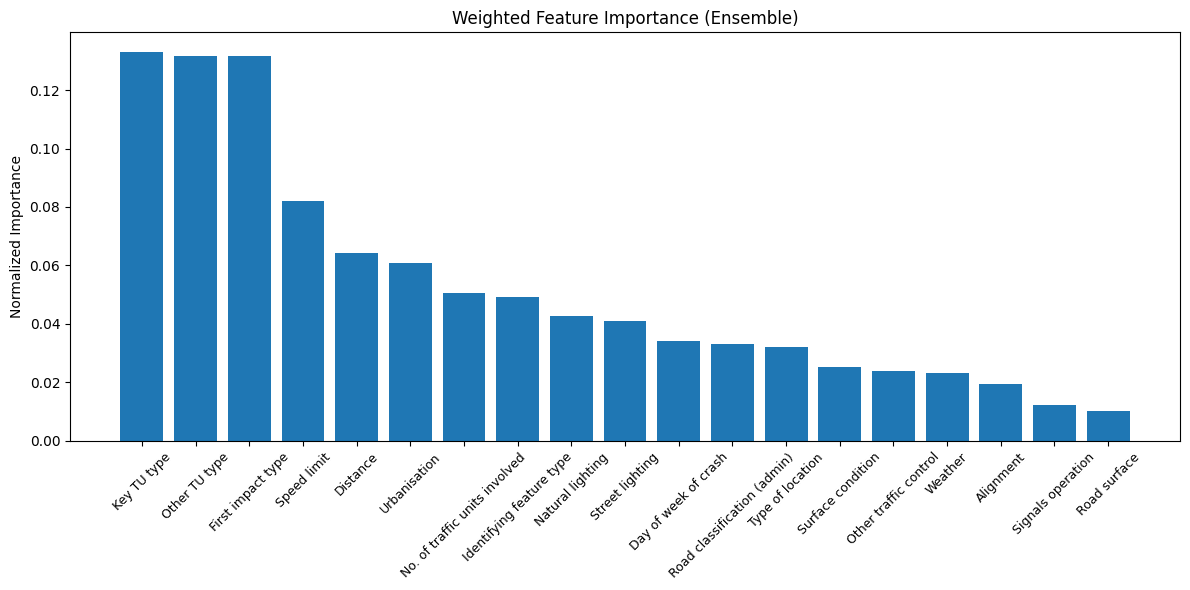

In [11]:
# plot feature importance
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(importance_df["Feature"], importance_df["Importance"])
ax.set_ylabel("Normalized Importance")
ax.set_title("Weighted Feature Importance (Ensemble)")
ax.tick_params(axis="x", rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig("figs/feature_importance.png", dpi=150)
print("\nFeature importance plot saved to feature_importance.png")


Fatal crash instances in test set: 423

Fatal crash profile plot saved to fatal_crash_profile.png


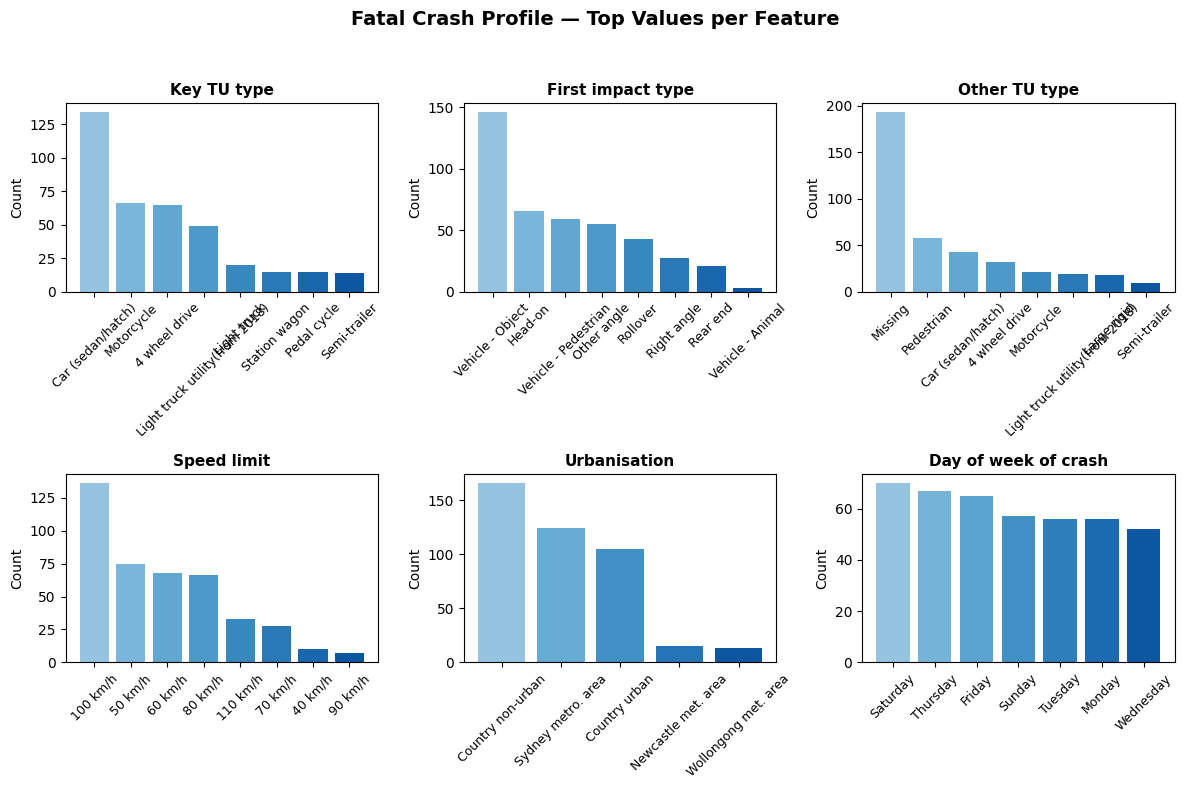

In [12]:
# fatal crash analysis plot
if TARGET in label_encoders:
    le_target = label_encoders[TARGET]
    fatal_label = le_target.transform(["Fatal"])[0]
else:
    fatal_label = "Fatal"
 
fatal_mask = y_test == fatal_label
fatal_cases = X_test[fatal_mask].copy()
 
print(f"\nFatal crash instances in test set: {fatal_cases.shape[0]}")
 
analysis_features = [
    "Key TU type",
    "First impact type",
    "Other TU type",
    "Speed limit",
    "Urbanisation",
    "Day of week of crash",
]
 
for feat in analysis_features:
    if feat in label_encoders:
        le = label_encoders[feat]
        decoded = le.inverse_transform(fatal_cases[feat].astype(int))
        top3 = pd.Series(decoded).value_counts().head(3)
    else:
        top3 = fatal_cases[feat].value_counts().head(3)

# plot 6 graphs at once 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
 
for i, feat in enumerate(analysis_features):
    ax = axes[i]
    if feat in label_encoders:
        le = label_encoders[feat]
        decoded = pd.Series(le.inverse_transform(fatal_cases[feat].astype(int)))
        counts = decoded.value_counts().head(8)
    else:
        counts = fatal_cases[feat].value_counts().head(8)
 
    labels = [str(l) for l in counts.index]
    colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(counts)))
 
    ax.bar(labels, counts.values, color=colors)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", labelsize=9, rotation=45)
 
fig.suptitle("Fatal Crash Profile — Top Values per Feature", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("figs/fatal_crash_profile.png", dpi=150)
print("\nFatal crash profile plot saved to fatal_crash_profile.png")

In [13]:
# evaluate on test set
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

# precision, recall, F1-score
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE (expected from paper)")
print("=" * 50)
print(f"ROC-AUC:   {roc_auc:.2f}   (paper: 0.68)")
print(f"Precision: {precision:.2f}   (paper: 0.33)")
print(f"Recall:    {recall:.2f}   (paper: 0.37)")
print(f"F1 Score:  {f1:.2f}   (paper: 0.33)")
print("=" * 50)


MODEL PERFORMANCE (expected from paper)
ROC-AUC:   0.68   (paper: 0.68)
Precision: 0.33   (paper: 0.33)
Recall:    0.37   (paper: 0.37)
F1 Score:  0.33   (paper: 0.33)


The next section we will try different methods not used in the paper. First off is Naive Bayes - we will try both with class-balancing and without and see how it compares.

In [129]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from imblearn.over_sampling import SMOTEN 

In [135]:
data = df.copy()

# Handle missing values for categorical features
data['Other TU type'] = data['Other TU type'].fillna('None/Other')

# Binning numerical features to make them categorical for CategoricalNB
data['Distance_Binned'] = pd.cut(data['Distance'], 
                                bins=[-1, 0, 10, 50, 100, 500, 1000, 10000, np.inf], 
                                labels=['0', '1-10', '11-50', '51-100', '101-500', '501-1000', '1001-10000', '>10000'])

data['TU_Binned'] = pd.cut(data['No. of traffic units involved'],
                          bins=[0, 1, 2, 3, 4, 5, np.inf],
                          labels=['1', '2', '3', '4', '5', '>5'])

# Replace original numeric features with binned versions
final_features = [f for f in FEATURES if f not in ['Distance', 'No. of traffic units involved']]
final_features += ['Distance_Binned', 'TU_Binned']

# Encode Features and Target
# Converting to string ensures they are treated as categorical by the encoder
X = data[final_features].astype(str)
y = data[TARGET]

enc = OrdinalEncoder()
X_encoded = enc.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [141]:
# 3. Split into Train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=440, stratify=y_encoded
)

Accuracy: 0.3834
Macro-Averaged ROC-AUC Score: 0.6746
                        precision    recall  f1-score   support

                 Fatal       0.07      0.34      0.12       423
    Minor/Other Injury       0.32      0.11      0.16      2271
       Moderate Injury       0.41      0.46      0.43      6095
Non-casualty (towaway)       0.43      0.51      0.47      2911
        Serious Injury       0.45      0.35      0.40      5411

              accuracy                           0.38     17111
             macro avg       0.34      0.35      0.32     17111
          weighted avg       0.41      0.38      0.38     17111



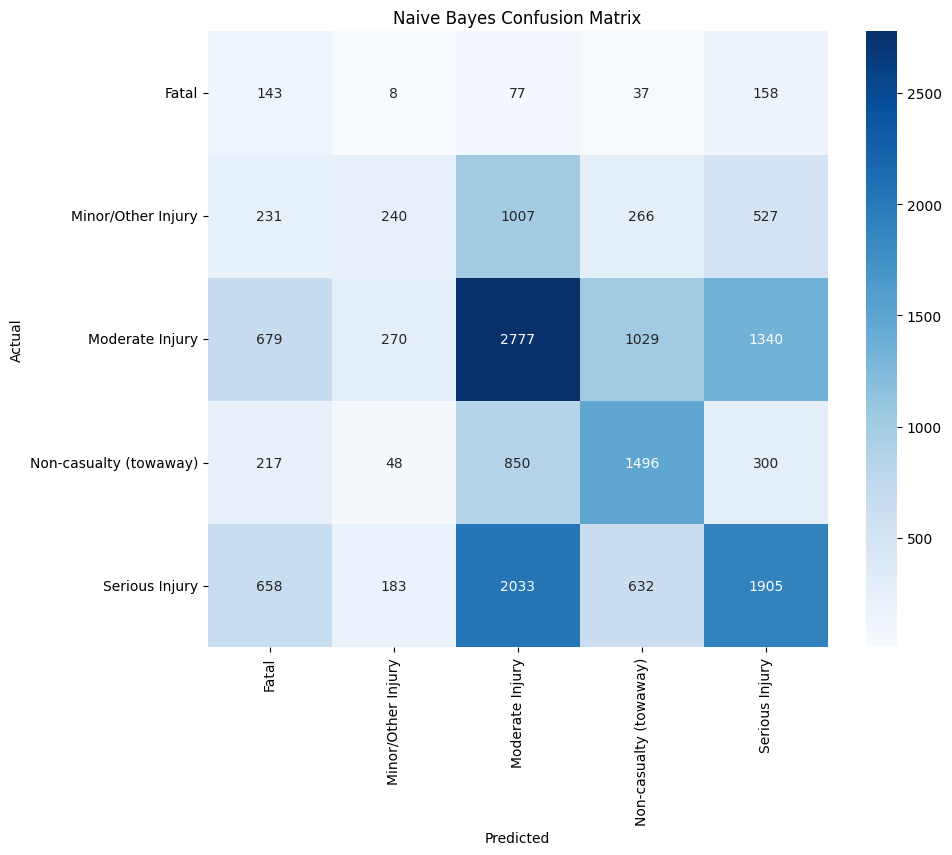

In [142]:
# No SMOTE

model = CategoricalNB(alpha=1.0) # Laplace smoothing
model.fit(X_train, y_train)

# 4A. Evaluation (No SMOTE)
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro-Averaged ROC-AUC Score: {roc_auc:.4f}")
#print(classification_report(y_test, y_pred, target_names=le.classes_))
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

# 5A. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.savefig('figs/naive_bayes_cm.png')

In [143]:
# Apply SMOTEN to balance the training set
# This variant is used because all features are now encoded as categorical indices
smote = SMOTEN(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize and train CategoricalNB on the resampled (balanced) data
model = CategoricalNB(alpha=1.0) # Laplace smoothing
model.fit(X_train_resampled, y_train_resampled)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


Accuracy: 0.3044
Macro-Averaged ROC-AUC Score: 0.6548
                        precision    recall  f1-score   support

                 Fatal       0.07      0.45      0.11       423
    Minor/Other Injury       0.20      0.38      0.26      2271
       Moderate Injury       0.42      0.23      0.29      6095
Non-casualty (towaway)       0.41      0.56      0.48      2911
        Serious Injury       0.45      0.21      0.29      5411

              accuracy                           0.30     17111
             macro avg       0.31      0.37      0.29     17111
          weighted avg       0.39      0.30      0.31     17111



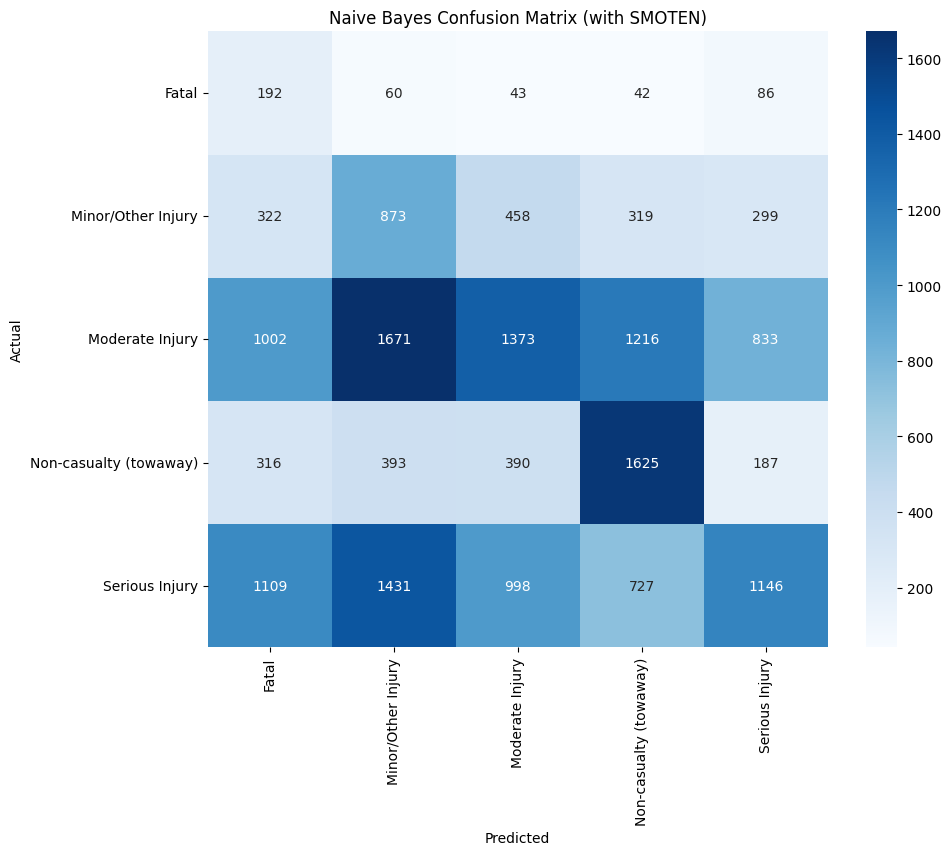

In [146]:
# 4B. Evaluation
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro-Averaged ROC-AUC Score: {roc_auc:.4f}")

print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

# 5B. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix (with SMOTEN)')
plt.savefig('figs/naive_bayes_smote_cm.png')